# Riyadh Domestic Air Traffic, 2021–2026

A small analysis of domestic flights from King Khalid International Airport using KKIA open data.

I wanted to look at how flight volume changed over time, which destinations were busiest and whether there were any obvious seasonal patterns. okay let's go!

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [46]:
df = pd.read_csv("../data/raw/opendata_2021-2026-domv43.csv")
df.head()

,Side,Type,Year,Month,DESTINATION City,Total of Flights,Total of Passengers
0,IN,Domestic,2021,Jan,Riyadh,4080,458875
1,OUT,Domestic,2021,Jan,Abha,403,45246
2,OUT,Domestic,2021,Jan,Al-Jawf,122,11344
3,OUT,Domestic,2021,Jan,Al-Ula,18,1187
4,OUT,Domestic,2021,Jan,Arar,109,9765


## okay now a quick look at the data

The file is already clean so I mainly checked the shape, missing values, column names & the destination naming before doing anything else.

In [47]:
print(df.shape)
print(df.isna().sum())
print(df.columns.tolist())

(1708, 7)
Side                   0
Type                   0
Year                   0
Month                  0
DESTINATION City       0
Total of Flights       0
Total of Passengers    0
dtype: int64
['Side', 'Type', 'Year', 'Month', 'DESTINATION City', 'Total of Flights', 'Total of Passengers']


In [48]:
df["DESTINATION City"].unique()

<StringArray>
[         'Riyadh',            'Abha',         'Al-Jawf',          'Al-Ula',
            'Arar',           'Bisha',          'Dammam',        'Al-Bahah',
        '\tQassim',           'Jizan',        'Qurayyat',   'Hafr Al-batin',
            'Hail',          'Jeddah',         'Madinah',          'Najran',
           'Rafha',        'Sharurah',           'Tabuk',            'Taif',
          'Turaif', 'WADI AL-DAWASER',         'Al Wajh',           'Yenbo',
            'NEOM',          'Qassim',         'Red Sea',         'Dawadmi',
         'Al-Ahsa',          'Aljouf',           'Alola',          'Gassim',
           'Gizan',          'Guriat',            'Wejh']
Length: 35, dtype: str

In [49]:
df = df.rename(columns={
    "Side": "side",
    "Type": "type",
    "Year": "year",
    "Month": "month",
    "DESTINATION City": "destination",
    "Total of Flights": "flights",
    "Total of Passengers": "passengers"
})

for col in ["side", "type", "month", "destination"]:
    df[col] = df[col].str.strip()

destination_map = {
    "Gassim": "Qassim",
    "Aljouf": "Al-Jawf",
    "Alola": "Al-Ula",
    "Gizan": "Jizan",
    "Wejh": "Al Wajh",
    "Yenbo": "Yanbu",
    "WADI AL-DAWASER": "Wadi Al-Dawaser"
}

df["destination"] = df["destination"].replace(destination_map)

In [50]:
df["date"] = pd.to_datetime(
    df["year"].astype(str) + "-" + df["month"],
    format="%Y-%b"
)

outbound = df[df["side"] == "OUT"].copy()

outbound["passengers_per_flight"] = (
    outbound["passengers"] / outbound["flights"]
)

outbound.head()

,side,type,year,month,destination,flights,passengers,date,passengers_per_flight
1,OUT,Domestic,2021,Jan,Abha,403,45246,2021-01-01,112.272953
2,OUT,Domestic,2021,Jan,Al-Jawf,122,11344,2021-01-01,92.983607
3,OUT,Domestic,2021,Jan,Al-Ula,18,1187,2021-01-01,65.944444
4,OUT,Domestic,2021,Jan,Arar,109,9765,2021-01-01,89.587156
5,OUT,Domestic,2021,Jan,Bisha,95,9800,2021-01-01,103.157895


## A few basic numbers

Well since I’m looking at flights leaving Riyadh, here i'll use the outbound rows for the rest of the analysis.

In [51]:
total_flights = outbound["flights"].sum()
total_passengers = outbound["passengers"].sum()
avg_passengers_per_flight = total_passengers / total_flights
destinations = outbound["destination"].nunique()

print(f"Flights: {total_flights:,}")
print(f"Passengers: {total_passengers:,}")
print(f"Passengers per flight: {avg_passengers_per_flight:.1f}")
print(f"Destinations: {destinations}")

Flights: 337,006
Passengers: 46,595,374
Passengers per flight: 138.3
Destinations: 29


## Time to style!

I kept the charts in the same muted green / cream palette so the final page would feel consistent.

In [52]:
BG = "#f7f3ec"
TEXT = "#1f2a23"
GREEN = "#355c45"
MID_GREEN = "#7f9f86"
LIGHT_GREEN = "#dce7dd"
SOFT = "#ebe6dd"

heatmap_cmap = LinearSegmentedColormap.from_list(
    "kkia_green",
    ["#f7f3ec", "#dce7dd", "#a8bea9", "#6f9076", "#355c45"]
)

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "axes.edgecolor": SOFT,
    "axes.labelcolor": TEXT,
    "text.color": TEXT,
    "xtick.color": TEXT,
    "ytick.color": TEXT,
    "font.size": 11
})

## Flights over time

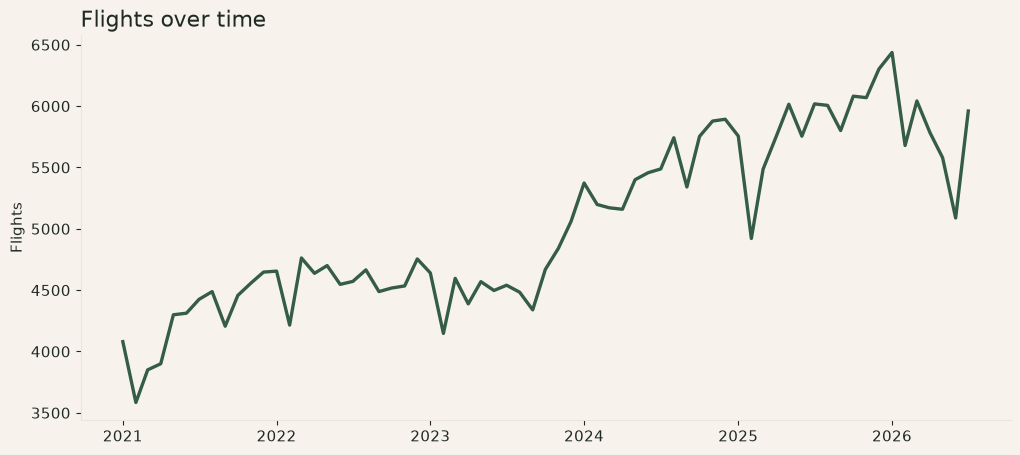

In [53]:
monthly = (
    outbound.groupby("date", as_index=False)
    .agg(
        flights=("flights", "sum"),
        passengers=("passengers", "sum")
    )
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly["date"],
    monthly["flights"],
    color=GREEN,
    linewidth=2.4
)

ax.set_title("Flights over time", loc="left", fontsize=16)
ax.set_ylabel("Flights")
ax.set_xlabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

The overall direction is pretty clear: domestic flight volume is higher in the later years, even though there are a few noticeable dips along the way.

## Busiest routes

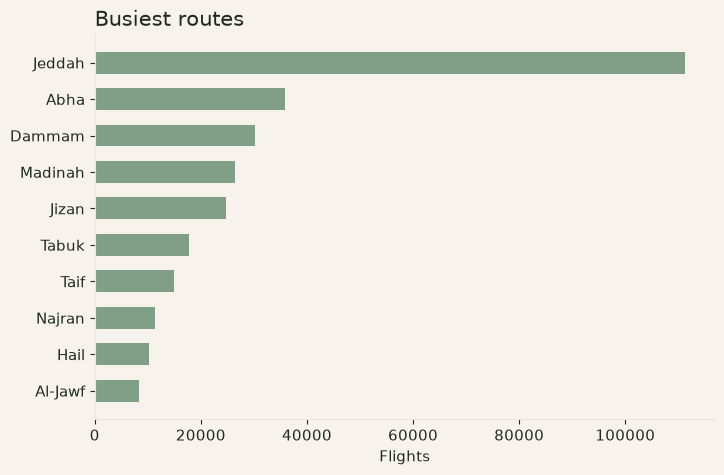

In [54]:
top_destinations = (
    outbound.groupby("destination", as_index=False)
    .agg(flights=("flights", "sum"))
    .sort_values("flights", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    top_destinations["destination"][::-1],
    top_destinations["flights"][::-1],
    color=MID_GREEN,
    height=0.6
)

ax.set_title("Busiest routes", loc="left", fontsize=15)
ax.set_xlabel("Flights")
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

Jeddah stands out by a lot, which makes alot of sense for one of the most busiest domestic connections from Riyadh.

## Monthly pattern

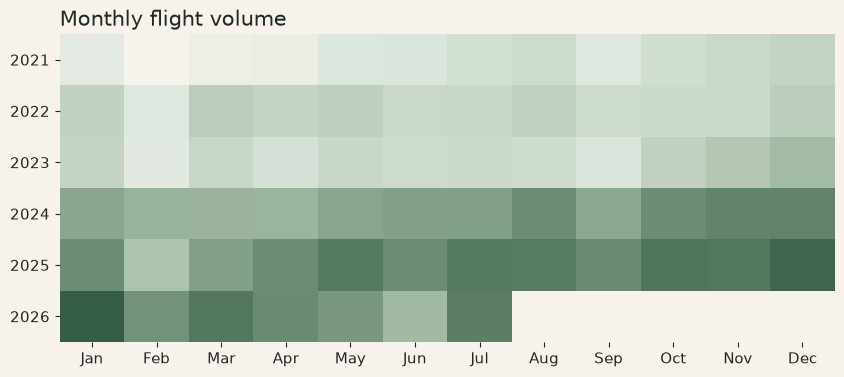

In [55]:
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

heatmap_data = (
    outbound.groupby(["year", "month"])["flights"]
    .sum()
    .unstack()
    .reindex(columns=month_order)
)

fig, ax = plt.subplots(figsize=(10, 4))

im = ax.imshow(
    heatmap_data,
    aspect="auto",
    cmap=heatmap_cmap
)

ax.set_xticks(range(len(month_order)))
ax.set_xticklabels(month_order)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_title("Monthly flight volume", loc="left", fontsize=15)
ax.set_xlabel("")
ax.set_ylabel("")

for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

2026 only goes up to July in this file, so the empty months at the end are missing data rather than zero flights.

## Domestic routes from Riyadh

In [56]:
city_coords = {
    "Riyadh": (24.7136, 46.6753),
    "Jeddah": (21.5433, 39.1728),
    "Dammam": (26.4207, 50.0888),
    "Abha": (18.2164, 42.5053),
    "Madinah": (24.5247, 39.5692),
    "Tabuk": (28.3838, 36.5550),
    "Taif": (21.2854, 40.4248),
    "Jizan": (16.8892, 42.5511),
    "Najran": (17.5656, 44.2289),
    "Hail": (27.5114, 41.7208),
    "Qassim": (26.3260, 43.9750),
    "Al-Ula": (26.6085, 37.9232),
    "Al-Jawf": (29.7854, 40.1007),
    "Yanbu": (24.0895, 38.0618),
    "Bisha": (19.9947, 42.6050),
    "Sharurah": (17.4667, 47.1167)
}

route_data = (
    outbound.groupby("destination", as_index=False)
    .agg(flights=("flights", "sum"))
)

route_data = route_data[
    route_data["destination"].isin(city_coords)
]

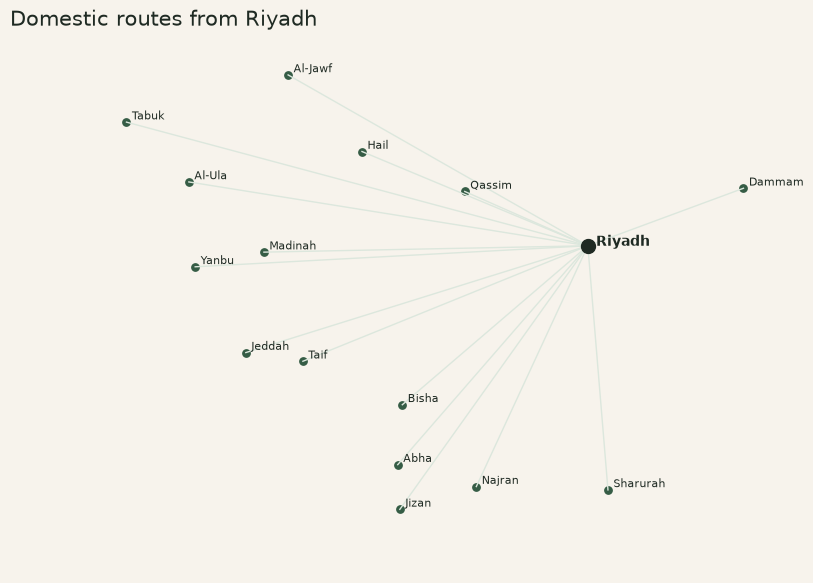

In [57]:
fig, ax = plt.subplots(figsize=(10, 7))

riyadh_lat, riyadh_lon = city_coords["Riyadh"]

for _, row in route_data.iterrows():
    city = row["destination"]

    if city == "Riyadh":
        continue

    lat, lon = city_coords[city]

    ax.plot(
        [riyadh_lon, lon],
        [riyadh_lat, lat],
        color=LIGHT_GREEN,
        linewidth=1
    )

    ax.scatter(lon, lat, s=28, color=GREEN)
    ax.text(lon + 0.12, lat + 0.08, city, fontsize=8, color=TEXT)

ax.scatter(riyadh_lon, riyadh_lat, s=100, color=TEXT, zorder=5)
ax.text(
    riyadh_lon + 0.18,
    riyadh_lat,
    "Riyadh",
    fontsize=10,
    fontweight="bold"
)

ax.set_title("Domestic routes from Riyadh", loc="left", fontsize=15)

ax.set_xlim(34, 51)
ax.set_ylim(15, 31)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

## (Omg it worked)

## Final page

I wanted the final visual to be something you could understand quickly with one look.

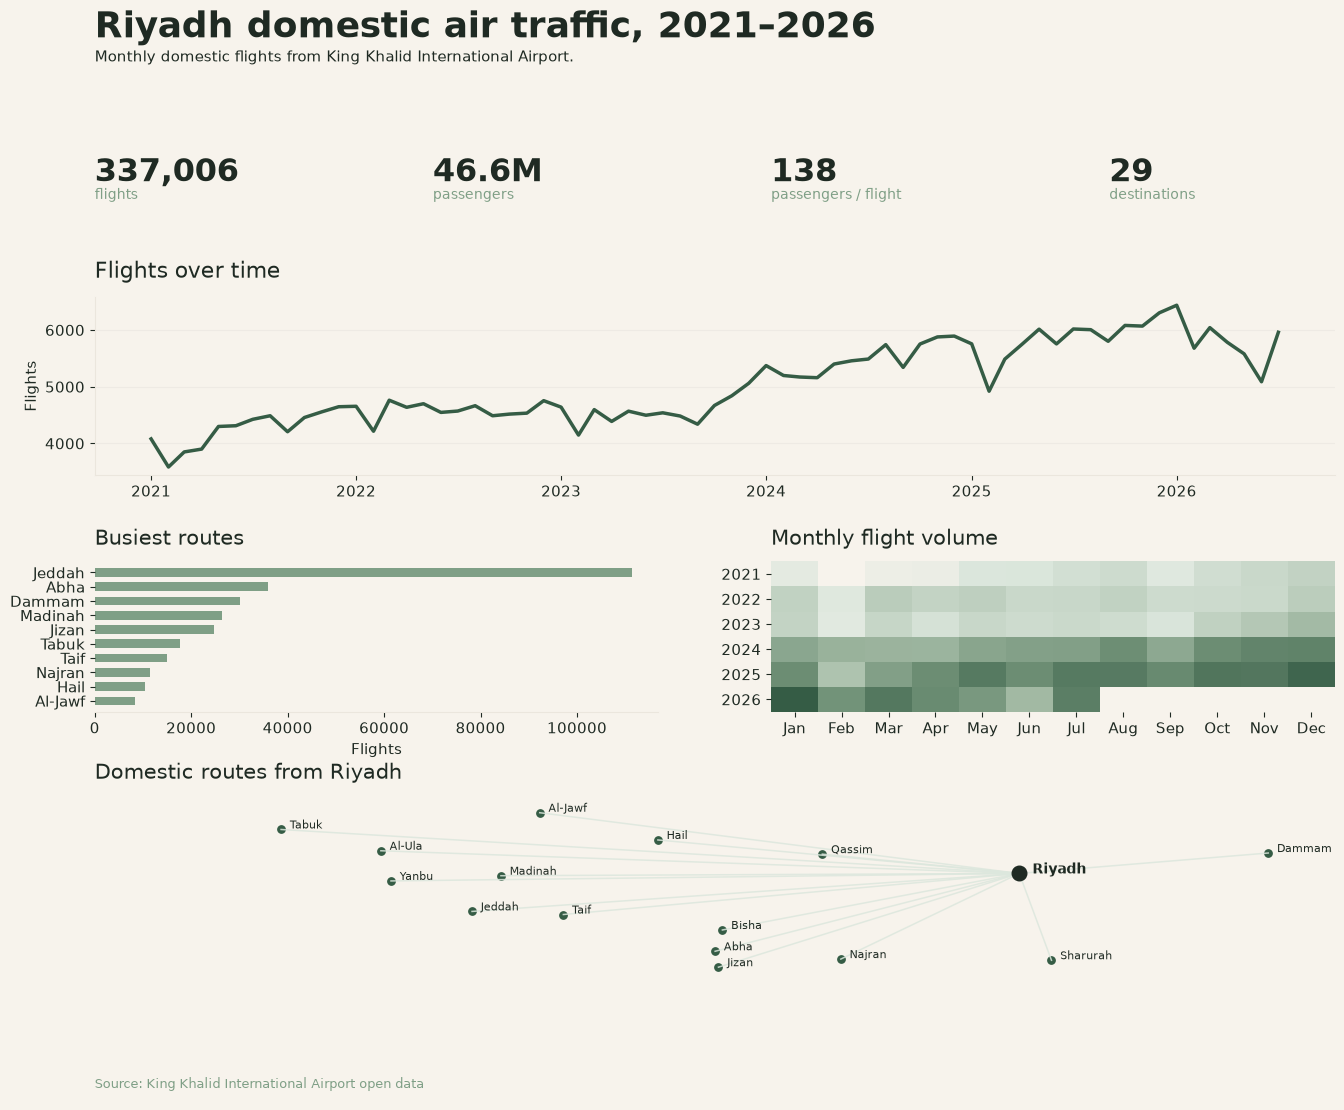

In [58]:
fig = plt.figure(figsize=(16, 14), facecolor=BG)

gs = fig.add_gridspec(
    6, 4,
    height_ratios=[0.8, 0.7, 2.6, 2.2, 2.8, 0.35],
    hspace=0.8,
    wspace=0.5
)

ax_title = fig.add_subplot(gs[0, :])
ax_title.axis("off")

ax_title.text(
    0.00, 0.72,
    "Riyadh domestic air traffic, 2021–2026",
    fontsize=26,
    fontweight="bold",
    color=TEXT
)

ax_title.text(
    0.00, 0.28,
    "Monthly domestic flights from King Khalid International Airport.",
    fontsize=11,
    color=TEXT
)

kpis = [
    (f"{total_flights:,}", "flights"),
    (f"{total_passengers / 1_000_000:.1f}M", "passengers"),
    (f"{avg_passengers_per_flight:.0f}", "passengers / flight"),
    (f"{destinations}", "destinations")
]

for i, (value, label) in enumerate(kpis):
    ax = fig.add_subplot(gs[1, i])
    ax.axis("off")

    ax.text(0.00, 0.62, value, fontsize=23, fontweight="bold", color=TEXT)
    ax.text(0.00, 0.25, label, fontsize=10, color=MID_GREEN)

ax1 = fig.add_subplot(gs[2, :])

ax1.plot(
    monthly["date"],
    monthly["flights"],
    color=GREEN,
    linewidth=2.5
)

ax1.set_title("Flights over time", loc="left", fontsize=16, pad=14)
ax1.set_ylabel("Flights")
ax1.set_xlabel("")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(axis="y", alpha=0.12)

ax2 = fig.add_subplot(gs[3, :2])

ax2.barh(
    top_destinations["destination"][::-1],
    top_destinations["flights"][::-1],
    color=MID_GREEN,
    height=0.6
)

ax2.set_title("Busiest routes", loc="left", fontsize=15, pad=12)
ax2.set_xlabel("Flights")
ax2.set_ylabel("")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)

ax3 = fig.add_subplot(gs[3, 2:])

ax3.imshow(
    heatmap_data,
    aspect="auto",
    cmap=heatmap_cmap
)

ax3.set_xticks(range(len(month_order)))
ax3.set_xticklabels(month_order)
ax3.set_yticks(range(len(heatmap_data.index)))
ax3.set_yticklabels(heatmap_data.index)
ax3.set_title("Monthly flight volume", loc="left", fontsize=15, pad=12)

for spine in ax3.spines.values():
    spine.set_visible(False)

ax4 = fig.add_subplot(gs[4, :])

for _, row in route_data.iterrows():
    city = row["destination"]

    if city == "Riyadh":
        continue

    lat, lon = city_coords[city]

    ax4.plot(
        [riyadh_lon, lon],
        [riyadh_lat, lat],
        color=LIGHT_GREEN,
        linewidth=1.1,
        alpha=0.85
    )

    ax4.scatter(lon, lat, s=28, color=GREEN)
    ax4.text(lon + 0.12, lat + 0.08, city, fontsize=8, color=TEXT)

ax4.scatter(riyadh_lon, riyadh_lat, s=110, color=TEXT, zorder=5)
ax4.text(
    riyadh_lon + 0.18,
    riyadh_lat,
    "Riyadh",
    fontsize=10,
    fontweight="bold",
    color=TEXT
)

ax4.set_title("Domestic routes from Riyadh", loc="left", fontsize=15, pad=14)
ax4.set_xlim(34, 51)
ax4.set_ylim(15, 31)
ax4.set_xticks([])
ax4.set_yticks([])

for spine in ax4.spines.values():
    spine.set_visible(False)

ax_footer = fig.add_subplot(gs[5, :])
ax_footer.axis("off")

ax_footer.text(
    0.00, 0.5,
    "Source: King Khalid International Airport open data",
    fontsize=9,
    color=MID_GREEN
)

plt.show()